### Import Library

In [ ]:
import os
import pandas as pd
import torch
from argparse import Namespace
from torch.utils.data import DataLoader
from model.ablation_model.MLPpatchLatentChannelMix import Model # Channel Mixed
# from model.MLPpatchLatent import Model # Channel Independence 

import sys
# sys.path.insert(1, "/Users/yeojisu/Documents/House-Price-Index-Prediction")

from config.KR_3 import *
from model.dfm_model import * 
from model.var_model import *
from model.kalman_filter import *
from utils.deep_learning import *
from utils.data_loader import *
from utils.visualization import *
import warnings
import seaborn as sns
import matplotlib.pyplot as plt

from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", message="A date index has been provided, but it has no associated frequency information")
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [64]:
window_size  = 6
forecast_size = 6
version = f"{window_size}_{forecast_size}_KR_mix"

### Load Data

In [65]:
target_df = load_target_data(TARGET_PATH)
target_df_train = target_df[target_df.index < TEST_DATE]
target_df_test  = target_df[target_df.index >= TEST_DATE]

### Dynamic Factor Model (DFM)

In [66]:
dfm_results = run_dfm(target_df_train, target_df_test, REFERENCE_DATE, 5)
# train phase 
optimal_factors = dfm_results["optimal_factors"]
shared_component_final_train = dfm_results["shared_component_final_train"]
loadings     = dfm_results["loadings"]
scale_factor = dfm_results["scale_factor"]
offset       = dfm_results["offset"]

combined_array = dfm_results["combined_shared_component"]

factor_column_list = []
for i in range(optimal_factors):
    factor_column_list.append("factor"+str(i+1))

factor_df = pd.DataFrame(combined_array, columns=factor_column_list, index=target_df.index)


Optimization terminated successfully.
         Current function value: 18.458637
         Iterations: 17
         Function evaluations: 9882


In [67]:
df = load_feature_data(FEATURE_PATH, FEATURE_COLUMN, TRAIN_DATE)
df = pd.concat([df, factor_df], axis=1)
df = df.dropna()

In [68]:
# First-order difference
data_diff = df.diff().dropna()
# Select explanatory variables using Granger test (excluding target)
granger_values = granger_test(data_diff[data_diff.index < TEST_DATE], "factor1", maxlag=23)

{'call_rate': 8, 'bond_3yr': 23, 'loan_rate_avg': 23, 'KOSPI': 9, 'NASDAQ': 9, 'M2_KR': 12, 'M2_US': 12, 'broad_liquidity': 19, 'CPI_growth': 23, 'USD_KRW_rate': 8, 'GDP_growth': 21, 'res_start': 2, 'res_permit': 4, 'factor2': 12}


In [70]:
data = data_diff[data_diff.index < TEST_DATE]
target = "factor2"
maxlag=23
granger_values = {}
significant_results = {}
for col in data.columns:
    if col != target:
        test_result = grangercausalitytests(data[[target, col]], maxlag=maxlag, verbose=False)
        sig_lags = {}
        
        for lag, result in test_result.items():
            f = result[0]['ssr_chi2test'][0]
            p_value = result[0]['ssr_chi2test'][1]
            if p_value <= 0.05:
                sig_lags[lag] = [round(f,3), round(p_value,3)]
        if sig_lags:
            significant_results[col] = sig_lags
granger_values[target] = significant_results
print(significant_results)

{'call_rate': {1: [6.488, 0.011], 3: [9.911, 0.019], 4: [10.798, 0.029], 5: [12.64, 0.027], 6: [13.952, 0.03], 7: [14.757, 0.039], 8: [23.035, 0.003], 9: [31.802, 0.0], 10: [33.368, 0.0], 11: [33.155, 0.0], 12: [33.743, 0.001], 13: [37.232, 0.0], 14: [35.849, 0.001], 15: [44.582, 0.0], 16: [48.566, 0.0], 17: [52.375, 0.0], 18: [54.46, 0.0], 19: [56.025, 0.0], 20: [64.956, 0.0], 21: [65.709, 0.0], 22: [66.687, 0.0], 23: [66.514, 0.0]}, 'bond_3yr': {1: [19.42, 0.0], 2: [16.476, 0.0], 3: [20.949, 0.0], 4: [27.271, 0.0], 5: [32.657, 0.0], 6: [33.85, 0.0], 7: [32.128, 0.0], 8: [31.397, 0.0], 9: [34.164, 0.0], 10: [34.064, 0.0], 11: [35.736, 0.0], 12: [40.797, 0.0], 13: [44.297, 0.0], 14: [45.865, 0.0], 15: [47.327, 0.0], 16: [49.199, 0.0], 17: [69.458, 0.0], 18: [70.353, 0.0], 19: [72.238, 0.0], 20: [69.49, 0.0], 21: [72.635, 0.0], 22: [76.706, 0.0], 23: [87.693, 0.0]}, 'loan_rate_avg': {1: [15.38, 0.0], 2: [6.366, 0.041], 3: [8.613, 0.035], 9: [21.866, 0.009], 10: [24.679, 0.006], 11: [24.

### Channel Correlation

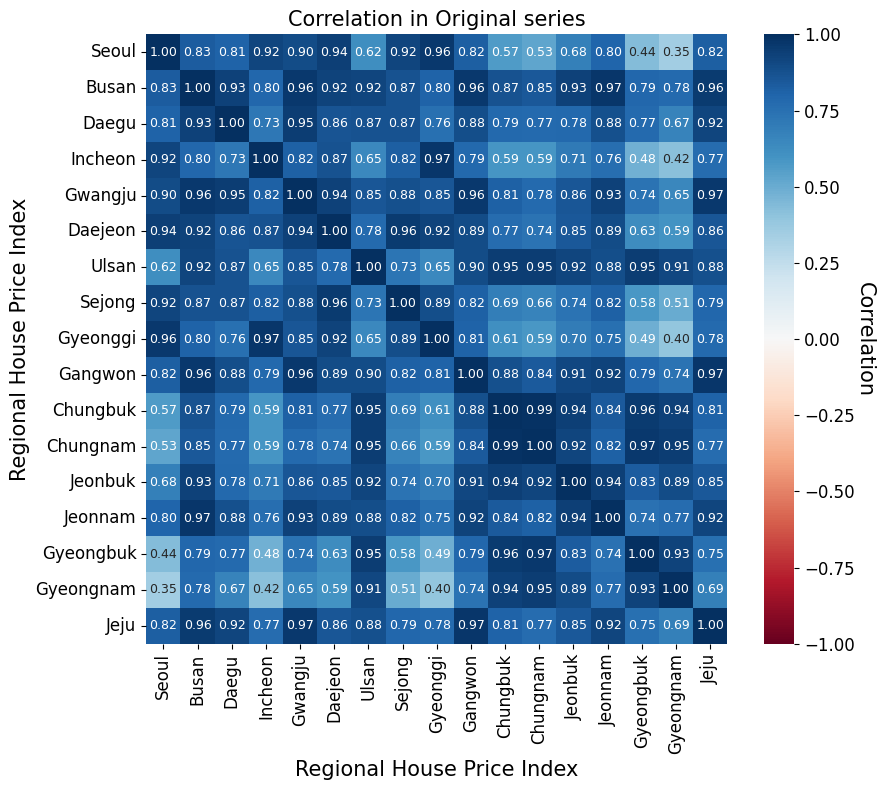

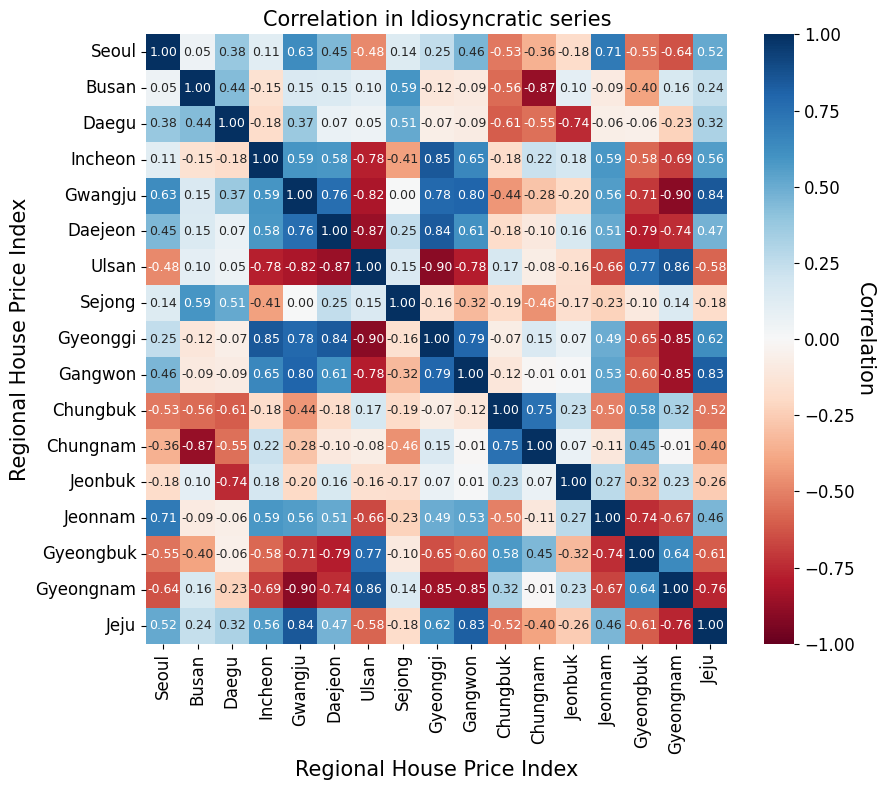

In [ ]:
target_mean = target_df_train.mean().values
shared_val = (factor_df.values @ loadings.T) * scale_factor + target_mean + offset
shared_comp = pd.DataFrame(shared_val, index=None)
shared_comp.index = target_df.index
shared_comp.columns = target_df.columns
shared_comp = shared_comp

plt.figure(figsize=(9, 8))
ax = sns.heatmap(
    target_df.corr(),
    annot=True, 
    fmt=".2f", 
    cmap="RdBu",
    center=0,
    vmin=-1,
    vmax=1,
    annot_kws={"size": 9} 
    )

# 제목 및 컬러바 라벨
plt.title("Correlation in Original series", fontsize=15)
cbar = ax.collections[0].colorbar
cbar.set_label("Correlation", rotation=270, labelpad=15, fontsize=15)
cbar.ax.tick_params(labelsize=12)
new_yticklabels = [label.replace("_HPI", "") for label in target_df.corr().columns]

plt.xlabel("Regional House Price Index", fontsize=15)
plt.ylabel("Regional House Price Index", fontsize=15)
plt.yticks(rotation=0, fontsize=12)
ax.set_xticklabels(new_yticklabels, fontsize=12)
ax.set_yticklabels(new_yticklabels, fontsize=12)
plt.tight_layout()
plt.savefig("corr_orign.pdf", format="pdf")
plt.show()

plt.figure(figsize=(9, 8))
ax = sns.heatmap(
    (target_df - shared_comp).corr(),
    annot=True, 
    fmt=".2f", 
    cmap="RdBu",
    center=0,
    vmin=-1,
    vmax=1,
    annot_kws={"size": 9} 
    )

# 제목 및 컬러바 라벨
plt.title("Correlation in Idiosyncratic series", fontsize=15)
cbar = ax.collections[0].colorbar
cbar.set_label("Correlation", rotation=270, labelpad=15, fontsize=15)
cbar.ax.tick_params(labelsize=12)
new_yticklabels = [label.replace("_HPI", "") for label in target_df.corr().columns]

plt.xlabel("Regional House Price Index", fontsize=15)
plt.ylabel("Regional House Price Index", fontsize=15)
plt.yticks(rotation=0, fontsize=12)
ax.set_xticklabels(new_yticklabels, fontsize=12)
ax.set_yticklabels(new_yticklabels, fontsize=12)
plt.tight_layout()
plt.savefig("corr_idio.pdf", format="pdf")
plt.show()

In [ ]:
abs_corr = target_df.corr().abs()
mask = np.eye(abs_corr.shape[0], dtype=bool)
mean_abs_offdiag = abs_corr.values[~mask].mean()
print(mean_abs_offdiag)

0.8064049222210166


In [ ]:
abs_corr = (target_df - shared_comp).corr().abs()
mask = np.eye(abs_corr.shape[0], dtype=bool)
mean_abs_offdiag = abs_corr.values[~mask].mean()
print(mean_abs_offdiag)

0.4161831077081233


### Vector Autoregression (VAR)

{'call_rate': 8, 'bond_3yr': 23, 'loan_rate_avg': 23, 'KOSPI': 9, 'NASDAQ': 9, 'M2_KR': 12, 'M2_US': 12, 'broad_liquidity': 19, 'CPI_growth': 23, 'USD_KRW_rate': 8, 'GDP_growth': 21, 'res_start': 2, 'res_permit': 4, 'factor2': 12}


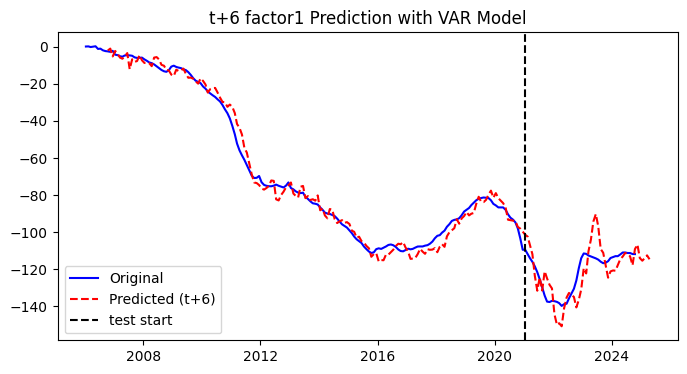

{'call_rate': 20, 'bond_3yr': 23, 'loan_rate_avg': 22, 'KOSPI': 22, 'KOSDAQ': 22, 'NASDAQ': 23, 'M2_KR': 23, 'M2_US': 18, 'broad_liquidity': 23, 'USD_KRW_rate': 22, 'GDP_growth': 23, 'res_permit': 20}


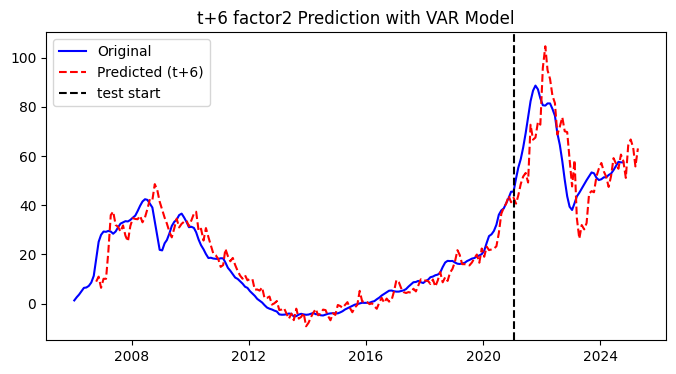

In [ ]:
forecast_dfs = {} 
for i in range(optimal_factors):
    factor_name = f"factor{i+1}"
    
    forecast_dfs[factor_name] = var_forecast(df, factor_name, TEST_DATE, MAXLAG_FACTOR, SELECTED_LAG_FACTOR, forecast_size)
    
    plot_var_forecast(df, forecast_dfs[factor_name], factor_name, TEST_DATE, forecast_size)

### Kalman Filter

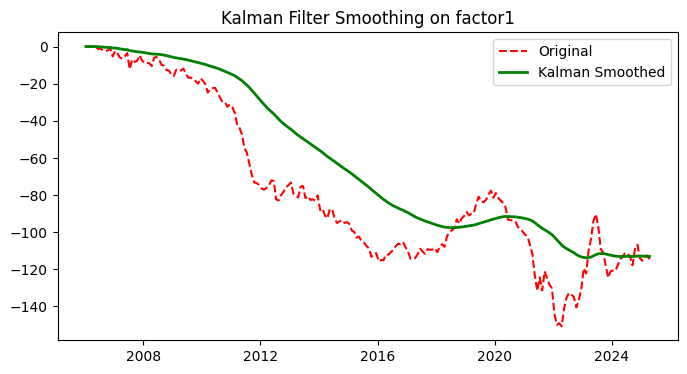

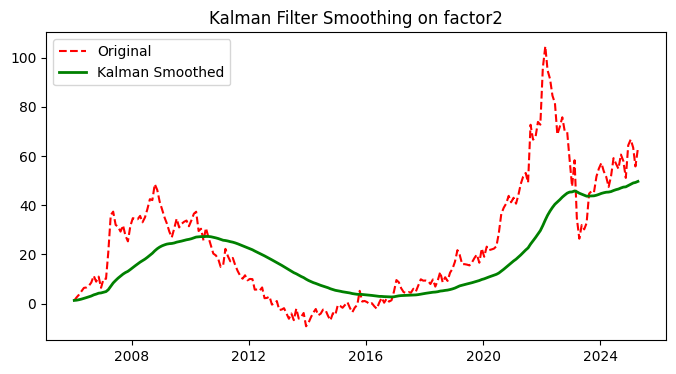

In [72]:
smoothed_factors = {} 
c=["#FF8383", "#5DB996"]
for i in range(optimal_factors):
    factor_name = f"factor{i+1}"
    combined_series = pd.concat([df[factor_name][TRAIN_DATE:TRAIN_DATE[:6]+str(forecast_size+SELECTED_LAG_FACTOR)+'-15'], forecast_dfs[factor_name][factor_name]])
    smoothed = apply_kalman_filter(combined_series, KALMAN_OBSERVATION_COV, KALMAN_TRANSITION_COV)
    plot_kalman_filter_result(combined_series, smoothed, factor_name)
    smoothed_factors[factor_name] = smoothed


### Deep Residual Learning

In [73]:
smoothed_factors_df = pd.concat(list(smoothed_factors.values()), axis=1)
smoothed_factors_df.columns = [f"factor{i+1}" for i in range(optimal_factors)]

common_index = target_df.index.intersection(smoothed_factors_df.index)
smoothed_factors_df = smoothed_factors_df.loc[common_index]
target_df_common = target_df.loc[common_index]

target_mean = target_df_train.mean().values
factors_adjusted = (smoothed_factors_df.values @ loadings.T) * scale_factor + target_mean + offset

resid = target_df_common - factors_adjusted
resid = resid.reset_index().rename(columns={"index": "Date"})
resid["Date"] = pd.to_datetime(resid["Date"])

### Run

/Users/yeojisu/opt/anaconda3/envs/cv2024/lib/python3.11/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
 12%|█▏        | 124/1000 [37:01<4:21:35, 17.92s/it]

Early stopping triggered.
Training time: 1.175114462592385


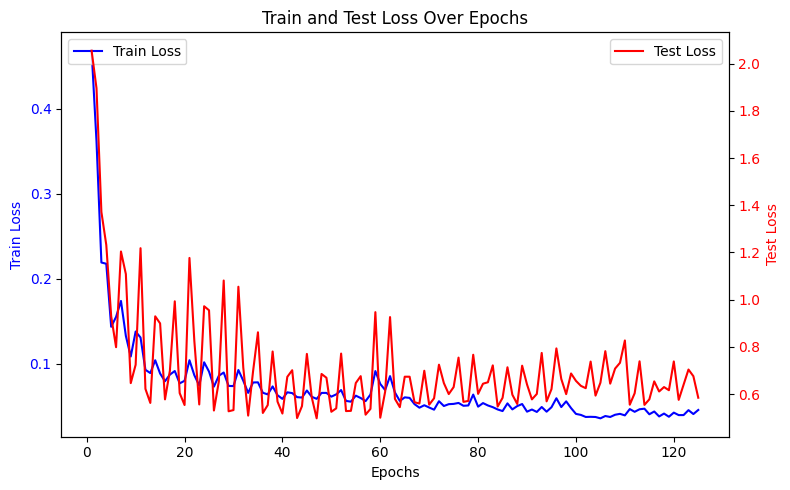

In [ ]:
idx = resid[resid['Date'] == pd.to_datetime(TEST_DATE)].index[0]
train_df = resid.iloc[:idx]
test_df  = resid.iloc[idx - (forecast_size + window_size):].reset_index(drop=True)

columns_to_use = resid.columns.drop("Date")
train_df_fe, test_df_fe, mean_, std_ = standardization(train_df, test_df, "Date", columns_to_use)
train_x, train_y, train_date_list = time_slide_df(train_df_fe, window_size, forecast_size, "Date", columns_to_use)
test_x, test_y, test_date_list   = time_slide_df(test_df_fe, window_size, forecast_size, "Date", columns_to_use)

configs = Namespace(
    seq_len      = window_size,
    pred_len     = forecast_size,
    enc_in       = len(columns_to_use),
    patch_len   = 3,
    patch_stride = 2,
    padding_patch= 'end',
    obs_cov = 1, # Kalman Filter Config
    trans_cov = 1,  # Kalman Filter Config
    d_model = 64,
    nhead = 4,
    num_layers = 3,
)
train_ds = Data(train_x, train_y)
test_ds  = Data(test_x, test_y)
batch_size = 16
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=False)
test_dl  = DataLoader(test_ds, batch_size=len(test_df), shuffle=False)

model = Model(configs=configs)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 1000
patience   = 20
save_path  = os.path.join(DIR_PATH, f"model{version}.pth")

train_loss_list, test_loss_list = train_deep_learning_model(model, train_dl, test_dl, criterion, optimizer, num_epochs, patience, save_path)
plot_loss_curve(train_loss_list, test_loss_list)

Draw the Results

In [ ]:
model.load_state_dict(torch.load(save_path))
model.eval()

train_outputs, train_targets = evaluate_model(model, DataLoader(train_ds, batch_size=len(train_ds), shuffle=False))
test_outputs, test_targets   = evaluate_model(model, DataLoader(test_ds, batch_size=len(test_ds), shuffle=False))


In [ ]:
N = 6
train_predicted = train_outputs[:, -N, :].cpu().numpy()
train_actual    = train_targets[:, -N, :].cpu().numpy()
train_dates = train_date_list[:, -N] 

test_predicted  = test_outputs[:, -N, :].cpu().numpy()
test_actual     = test_targets[:, -N, :].cpu().numpy()
test_dates = test_date_list[:, -N] 

plot_deep_learning_results(resid, columns_to_use, train_dates, test_dates,
                           train_actual, train_predicted, test_actual, test_predicted,
                           mean_, std_,
                           DIR_PATH, VERSION)

In [ ]:
N = 5
train_predicted = train_outputs[:, -N, :].cpu().numpy()
train_actual    = train_targets[:, -N, :].cpu().numpy()
train_dates = train_date_list[:, -N] 

test_predicted  = test_outputs[:, -N, :].cpu().numpy()
test_actual     = test_targets[:, -N, :].cpu().numpy()
test_dates = test_date_list[:, -N] 

plot_deep_learning_results(resid, columns_to_use, train_dates, test_dates,
                           train_actual, train_predicted, test_actual, test_predicted,
                           mean_, std_,
                           DIR_PATH, VERSION)

In [ ]:
N = 4
train_predicted = train_outputs[:, -N, :].cpu().numpy()
train_actual    = train_targets[:, -N, :].cpu().numpy()
train_dates = train_date_list[:, -N] 

test_predicted  = test_outputs[:, -N, :].cpu().numpy()
test_actual     = test_targets[:, -N, :].cpu().numpy()
test_dates = test_date_list[:, -N] 

plot_deep_learning_results(resid, columns_to_use, train_dates, test_dates,
                           train_actual, train_predicted, test_actual, test_predicted,
                           mean_, std_,
                           DIR_PATH, VERSION)

In [ ]:
N = 3
train_predicted = train_outputs[:, -N, :].cpu().numpy()
train_actual    = train_targets[:, -N, :].cpu().numpy()
train_dates = train_date_list[:, -N] 

test_predicted  = test_outputs[:, -N, :].cpu().numpy()
test_actual     = test_targets[:, -N, :].cpu().numpy()
test_dates = test_date_list[:, -N] 

plot_deep_learning_results(resid, columns_to_use, train_dates, test_dates,
                           train_actual, train_predicted, test_actual, test_predicted,
                           mean_, std_,
                           DIR_PATH, VERSION)

In [ ]:
N = 2
train_predicted = train_outputs[:, -N, :].cpu().numpy()
train_actual    = train_targets[:, -N, :].cpu().numpy()
train_dates = train_date_list[:, -N] 

test_predicted  = test_outputs[:, -N, :].cpu().numpy()
test_actual     = test_targets[:, -N, :].cpu().numpy()
test_dates = test_date_list[:, -N] 

plot_deep_learning_results(resid, columns_to_use, train_dates, test_dates,
                           train_actual, train_predicted, test_actual, test_predicted,
                           mean_, std_,
                           DIR_PATH, VERSION)

In [ ]:
N = 1
train_predicted = train_outputs[:, -N, :].cpu().numpy()
train_actual    = train_targets[:, -N, :].cpu().numpy()
train_dates = train_date_list[:, -N] 

test_predicted  = test_outputs[:, -N, :].cpu().numpy()
test_actual     = test_targets[:, -N, :].cpu().numpy()
test_dates = test_date_list[:, -N] 

plot_deep_learning_results(resid, columns_to_use, train_dates, test_dates,
                           train_actual, train_predicted, test_actual, test_predicted,
                           mean_, std_,
                           DIR_PATH, VERSION)